# Action Rules with Confidence Intervals — IBM HR Employee Attrition

Employee attrition is one of the most costly problems in human resources. Replacing a single employee can cost 50–200% of their annual salary, and the loss of institutional knowledge is often immeasurable. Action rules offer a principled way to answer: *what interventions would reduce attrition risk for a specific employee profile?*

This notebook demonstrates the full **action-rules** workflow on the **IBM HR Analytics Employee Attrition** dataset (~1,470 employees, ~16% attrition). Because the dataset is relatively small, we pay particular attention to **quantifying uncertainty** in the discovered rules using confidence intervals.

**What you will learn:**

1. How to preprocess HR data for action rule mining
2. How to configure and run `ActionRules.fit()` with utility tables
3. How to compute confidence intervals with Bootstrap, Analytic (Wald), and Bayesian methods
4. How to visualize uncertainty and compare methods
5. How to categorize rules as Accept, Reject, or Uncertain
6. How to interpret **realistic rule gain** — the economic value of each intervention

**Requirements:** `pip install action-rules[viz]` (adds scipy + matplotlib)

## 1. Setup and Data Loading

We use the **IBM HR Analytics Employee Attrition** dataset, originally released by IBM data scientists and widely used as a benchmark for HR analytics. It contains 1,470 employee records with 35 features including demographics, job characteristics, satisfaction scores, and whether the employee left the company (`Attrition`).

We download the dataset from a public GitHub mirror if it is not already cached locally.

In [1]:
import os
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

In [2]:
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data", "employee_attrition.csv")

PRIMARY_URL = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/HR-Employee-Attrition.csv"
FALLBACK_URL = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    try:
        print(f"Downloading from primary source...")
        urllib.request.urlretrieve(PRIMARY_URL, DATA_PATH)
        print(f"Saved to: {DATA_PATH}")
    except Exception as e:
        print(f"Primary source failed ({e}), trying fallback...")
        try:
            urllib.request.urlretrieve(FALLBACK_URL, DATA_PATH)
            print(f"Saved to: {DATA_PATH}")
        except Exception as e2:
            raise RuntimeError(
                f"Could not download the dataset.\n"
                f"Primary URL:  {PRIMARY_URL}\n"
                f"Fallback URL: {FALLBACK_URL}\n"
                f"Please download manually and save to: {DATA_PATH}\n"
                f"Error: {e2}"
            )
else:
    print(f"Dataset already cached at: {DATA_PATH}")

data_raw = pd.read_csv(DATA_PATH)
print(f"\nDataset shape: {data_raw.shape[0]} rows x {data_raw.shape[1]} columns")
data_raw.head(3)

Dataset already cached at: C:\Users\LukasSykora\OneDrive - Ogilvy\Documents\Soukrome\action rules\action-rules\notebooks\ci\data\employee_attrition.csv

Dataset shape: 1470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [3]:
print("Target variable (Attrition) distribution:")
print(data_raw["Attrition"].value_counts())
print(f"\nAttrition rate: {(data_raw['Attrition'] == 'Yes').mean():.1%}")

Target variable (Attrition) distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


## 2. Preprocessing

The raw dataset contains 35 columns, several of which are non-informative (constants or identifiers). We:

1. Drop columns that carry no signal: `EmployeeCount` (all 1), `Over18` (all Y), `StandardHours` (all 80), `EmployeeNumber` (unique ID).
2. Discretize numeric attributes into interpretable bins so the mined rules are human-readable.
3. Map ordinal satisfaction scores to descriptive labels.
4. Select only the columns relevant to our mining task.

In [4]:
data = data_raw.copy()

# Drop non-informative columns
data.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], inplace=True)

# Discretize: Age
data["Age"] = pd.cut(
    data["Age"],
    bins=[0, 29, 45, 200],
    labels=["young", "middle", "senior"],
    right=True,
)

# Discretize: MonthlyIncome
data["MonthlyIncome"] = pd.cut(
    data["MonthlyIncome"],
    bins=[0, 2999, 7000, float("inf")],
    labels=["low", "medium", "high"],
    right=True,
)

# Discretize: YearsAtCompany
data["YearsAtCompany"] = pd.cut(
    data["YearsAtCompany"],
    bins=[-1, 2, 10, float("inf")],
    labels=["new", "mid", "veteran"],
    right=True,
)

# Discretize: DistanceFromHome
data["DistanceFromHome"] = pd.cut(
    data["DistanceFromHome"],
    bins=[0, 4, 15, float("inf")],
    labels=["near", "moderate", "far"],
    right=True,
)

# Map ordinal scales to descriptive labels
work_life_balance_map = {1: "bad", 2: "good", 3: "better", 4: "best"}
job_satisfaction_map = {1: "low", 2: "medium", 3: "high", 4: "very_high"}
env_satisfaction_map = {1: "low", 2: "medium", 3: "high", 4: "very_high"}

data["WorkLifeBalance"] = data["WorkLifeBalance"].map(work_life_balance_map)
data["JobSatisfaction"] = data["JobSatisfaction"].map(job_satisfaction_map)
data["EnvironmentSatisfaction"] = data["EnvironmentSatisfaction"].map(env_satisfaction_map)

# Convert any remaining categoricals to string to avoid dtype issues
for col in ["Age", "MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]:
    data[col] = data[col].astype(str)

# Select only the columns we need for mining
columns_to_keep = [
    "Age",
    "Gender",
    "MaritalStatus",
    "Department",
    "OverTime",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "MonthlyIncome",
    "Attrition",
]
data = data[columns_to_keep].copy()

print(f"Final dataset shape: {data.shape}")
print(f"\nColumn dtypes:")
print(data.dtypes)
data.head(5)

Final dataset shape: (1470, 10)

Column dtypes:
Age                        object
Gender                     object
MaritalStatus              object
Department                 object
OverTime                   object
JobSatisfaction            object
EnvironmentSatisfaction    object
WorkLifeBalance            object
MonthlyIncome              object
Attrition                  object
dtype: object


,Age,Gender,MaritalStatus,Department,OverTime,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,MonthlyIncome,Attrition
0,middle,Female,Single,Sales,Yes,very_high,medium,bad,medium,Yes
1,senior,Male,Married,Research & Development,No,medium,high,better,medium,No
2,middle,Male,Single,Research & Development,Yes,high,very_high,better,low,Yes
3,middle,Female,Married,Research & Development,Yes,high,very_high,better,low,No
4,young,Male,Married,Research & Development,No,medium,low,better,medium,No


In [5]:
# Verify no missing values remain
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing: {data.isnull().sum().sum()}")

Missing values per column:
Age                        0
Gender                     0
MaritalStatus              0
Department                 0
OverTime                   0
JobSatisfaction            0
EnvironmentSatisfaction    0
WorkLifeBalance            0
MonthlyIncome              0
Attrition                  0
dtype: int64

Total missing: 0


## 3. Mining Action Rules

We configure the miner with:

- **Stable attributes**: `Age`, `Gender`, `MaritalStatus`, `Department` — characteristics of an employee that we cannot (or would not) change.
- **Flexible attributes**: `OverTime`, `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`, `MonthlyIncome` — factors that HR interventions can influence.
- **Target**: `Attrition` — we seek rules that shift employees from `Yes` (leaving) to `No` (staying).

We also define **utility tables** to quantify the economic impact of each state and transition. This enables computation of the **realistic rule gain** — the expected net monetary value of applying a rule to employees who match the antecedent conditions.

> **Note on thresholds**: With only ~237 attrition cases in 1,470 records, we use support thresholds of 20 and confidence thresholds of 0.6 to obtain a focused, manageable rule set (~45 rules). The confidence interval analysis in later sections will reveal which of these rules are statistically robust.

In [6]:
from action_rules import ActionRules

# Define attribute roles
stable_attributes = ["Age", "Gender", "MaritalStatus", "Department"]
flexible_attributes = [
    "OverTime",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "MonthlyIncome",
]

# Utility tables: economic value of employee states and HR interventions
# Retaining an employee is worth ~$5,000 (conservative estimate of reduced turnover cost)
intrinsic_utility_table = {
    ("Attrition", "No"): 5000.0,
    ("Attrition", "Yes"): 0.0,
    ("OverTime", "No"): 0.0,
    ("OverTime", "Yes"): -200.0,
    ("MonthlyIncome", "low"): -3000.0,
    ("MonthlyIncome", "medium"): -5000.0,
    ("MonthlyIncome", "high"): -8000.0,
    ("EnvironmentSatisfaction", "low"): 0.0,
    ("EnvironmentSatisfaction", "medium"): -500.0,
    ("EnvironmentSatisfaction", "high"): -1000.0,
    ("EnvironmentSatisfaction", "very_high"): -1500.0,
}

# Transition costs: what it costs to implement each intervention
transition_utility_table = {
    ("OverTime", "Yes", "No"): -100.0,
    ("MonthlyIncome", "low", "medium"): -2000.0,
    ("MonthlyIncome", "medium", "high"): -3000.0,
    ("EnvironmentSatisfaction", "low", "medium"): -500.0,
    ("EnvironmentSatisfaction", "medium", "high"): -500.0,
}

# Create and fit the miner
ar = ActionRules(
    min_stable_attributes=2,
    min_flexible_attributes=1,
    min_undesired_support=20,
    min_desired_support=20,
    min_undesired_confidence=0.6,
    min_desired_confidence=0.6,
    verbose=False,
    intrinsic_utility_table=intrinsic_utility_table,
    transition_utility_table=transition_utility_table,
)

ar.fit(
    data=data,
    stable_attributes=stable_attributes,
    flexible_attributes=flexible_attributes,
    target="Attrition",
    target_undesired_state="Yes",
    target_desired_state="No",
    use_sparse_matrix=True,
)

rules = ar.get_rules()
n_rules = len(rules.action_rules)
print(f"Mined {n_rules} action rules")

Mined 12 action rules


In [7]:
# Display the first 10 rules in human-readable notation
pretty_rules = rules.get_pretty_ar_notation()
for i, rule_text in enumerate(pretty_rules[:10]):
    print(f"Rule {i}: {rule_text}\n")

if n_rules > 10:
    print(f"... and {n_rules - 10} more rules.")

Rule 0: If attribute 'Age' is 'young', attribute 'MaritalStatus' is 'Single', attribute 'OverTime' value 'Yes' is changed to 'No', then 'Attrition' value 'Yes' is changed to 'No with support: 27, confidence: 0.4747252747252748, uplift: 0.010293787844808255, support of undesired part: 27, confidence of undesired part: 0.675, support of desired part: 64, confidence of desired part: 0.7032967032967034, max_rule_gain: 5100.0, realistic_rule_gain: 1991.483516483517, realistic_dataset_gain: 79659.34065934068.

Rule 1: If attribute 'MaritalStatus' is 'Single', attribute 'Department' is 'Sales', attribute 'OverTime' value 'Yes' is changed to 'No', then 'Attrition' value 'Yes' is changed to 'No with support: 32, confidence: 0.521193092621664, uplift: 0.015037938252223968, support of undesired part: 32, confidence of undesired part: 0.6530612244897959, support of desired part: 83, confidence of desired part: 0.7980769230769231, max_rule_gain: 5100.0, realistic_rule_gain: 2355.690737833595, reali

## 4. Confidence Intervals — Overview

A point estimate like "uplift = 0.15" tells us the direction and magnitude of an effect, but nothing about its uncertainty. With a small dataset like this one (~237 attrition events), confidence intervals are *especially* important — rules mined on small samples can easily be statistical noise.

The `action-rules` package provides three complementary CI methods:

| Method | Principle | Strengths | Limitations |
|--------|-----------|-----------|-------------|
| **Bootstrap** | Resample data B times, compute statistic on each resample, use percentiles as CI | Non-parametric, no distributional assumptions, intuitive | Computationally intensive; B ≥ 1000 recommended for production |
| **Analytic (Wald)** | Apply delta method to propagate binomial variance through the uplift formula | Instantaneous, closed-form, easily auditable | Requires large-sample normal approximation; may underestimate uncertainty on small data |
| **Bayesian** | Beta-Binomial conjugate model; draw MC samples from posterior | Full posterior distribution; handles small samples gracefully; direct probabilistic interpretation | Requires prior specification; slightly slower than analytic |

> **Recommendation for small datasets**: The Bayesian method tends to produce better-calibrated intervals when sample sizes are small, because it naturally regularizes through the prior. For this dataset, compare all three methods and note where they disagree.

## 5. Bootstrap Confidence Intervals

The non-parametric percentile bootstrap resamples the dataset with replacement 500 times and computes the uplift statistic on each resample. The 2.5th and 97.5th percentiles of this empirical distribution form the 95% CI.

In [8]:
%%time

results_boot = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>26} | {'SE':>8}")
print("-" * 62)
for r in results_boot:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {r.uplift_se:>8.6f}"
    )

  Rule |     Uplift |                     95% CI |       SE
--------------------------------------------------------------
     0 |   0.010327 | [  0.004829,   0.016354] | 0.003099
     1 |   0.015435 | [  0.009907,   0.022193] | 0.003177
     2 |   0.009019 | [  0.004637,   0.014790] | 0.002536
     3 |   0.011170 | [  0.006307,   0.016491] | 0.002677
     4 |   0.011570 | [  0.005804,   0.017470] | 0.002997
     5 |   0.008298 | [  0.003016,   0.013764] | 0.002741
     6 |   0.010840 | [  0.005228,   0.016844] | 0.002908
     7 |   0.014279 | [  0.008276,   0.020424] | 0.003204
     8 |   0.013814 | [  0.007870,   0.019632] | 0.003087
     9 |   0.009667 | [  0.004991,   0.014934] | 0.002646
    10 |   0.012293 | [  0.007085,   0.017988] | 0.002831
    11 |   0.008518 | [  0.002977,   0.014208] | 0.002854
CPU times: total: 188 ms
Wall time: 187 ms


## 6. Analytic (Wald) Confidence Intervals

The analytic method uses the **delta method** to propagate uncertainty from the two binomial confidence estimates (undesired-side and desired-side) through the uplift formula. It is orders of magnitude faster than the bootstrap and produces very similar results when sample sizes are adequate.

In [9]:
%%time

results_anal = ar.confidence_intervals(
    data,
    method="analytic",
    confidence_level=0.95,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>26} | {'SE':>8}")
print("-" * 62)
for r in results_anal:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {r.uplift_se:>8.6f}"
    )

  Rule |     Uplift |                     95% CI |       SE
--------------------------------------------------------------
     0 |   0.010294 | [  0.005590,   0.014997] | 0.002400
     1 |   0.015038 | [  0.009905,   0.020171] | 0.002619
     2 |   0.009073 | [  0.005251,   0.012896] | 0.001950
     3 |   0.011069 | [  0.007405,   0.014733] | 0.001870
     4 |   0.011689 | [  0.007708,   0.015670] | 0.002031
     5 |   0.008260 | [  0.003531,   0.012990] | 0.002413
     6 |   0.011017 | [  0.006272,   0.015762] | 0.002421
     7 |   0.014201 | [  0.009699,   0.018703] | 0.002297
     8 |   0.013763 | [  0.009918,   0.017609] | 0.001962
     9 |   0.009498 | [  0.005301,   0.013694] | 0.002141
    10 |   0.012252 | [  0.008341,   0.016164] | 0.001996
    11 |   0.008652 | [  0.003626,   0.013679] | 0.002565
CPU times: total: 1.06 s
Wall time: 2.29 s


## 7. Bayesian Credible Intervals

The Bayesian approach places **Beta(1, 1)** (uniform) priors on each group proportion and updates them with the observed data counts. Monte Carlo samples are drawn from the resulting Beta posteriors and composed into an uplift distribution via the uplift formula. The 2.5th and 97.5th percentiles of this posterior distribution form the 95% **credible interval**.

Unlike the frequentist CI, the Bayesian credible interval has a direct probabilistic interpretation: *given the data and our prior beliefs, there is a 95% probability that the true uplift lies within this interval*.

In [10]:
%%time

results_bayes = ar.confidence_intervals(
    data,
    method="bayesian",
    confidence_level=0.95,
    n_mc=10000,
    random_state=42,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% Credible Interval':>26} | {'SE':>8}")
print("-" * 62)
for r in results_bayes:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {r.uplift_se:>8.6f}"
    )

  Rule |     Uplift |      95% Credible Interval |       SE
--------------------------------------------------------------
     0 |   0.009973 | [  0.005157,   0.014332] | 0.002331
     1 |   0.014691 | [  0.009526,   0.019528] | 0.002573
     2 |   0.008679 | [  0.004789,   0.012119] | 0.001880
     3 |   0.010608 | [  0.006838,   0.013961] | 0.001821
     4 |   0.011348 | [  0.007397,   0.014979] | 0.001952
     5 |   0.007823 | [  0.002987,   0.012208] | 0.002339
     6 |   0.010687 | [  0.005899,   0.015111] | 0.002362
     7 |   0.013751 | [  0.009169,   0.017962] | 0.002244
     8 |   0.013195 | [  0.009266,   0.016775] | 0.001927
     9 |   0.009140 | [  0.004887,   0.012996] | 0.002079
    10 |   0.011850 | [  0.007771,   0.015513] | 0.001977
    11 |   0.008146 | [  0.003107,   0.012811] | 0.002500
CPU times: total: 46.9 ms
Wall time: 42.5 ms


## 8. Visualization

Numerical tables can be hard to scan. The `action_rules.visualization` module provides four complementary plot types.

In [11]:
from action_rules.visualization import bootstrap_histogram, forest_plot, grouped_forest_plot, posterior_plot

### 8.1 Bootstrap Histogram (Single Rule)

This histogram shows the empirical distribution of the uplift statistic across all 500 bootstrap resamples for a single rule. The shaded region marks the 95% CI. A roughly symmetric, bell-shaped distribution suggests that the analytic (normal) approximation is appropriate for this rule.

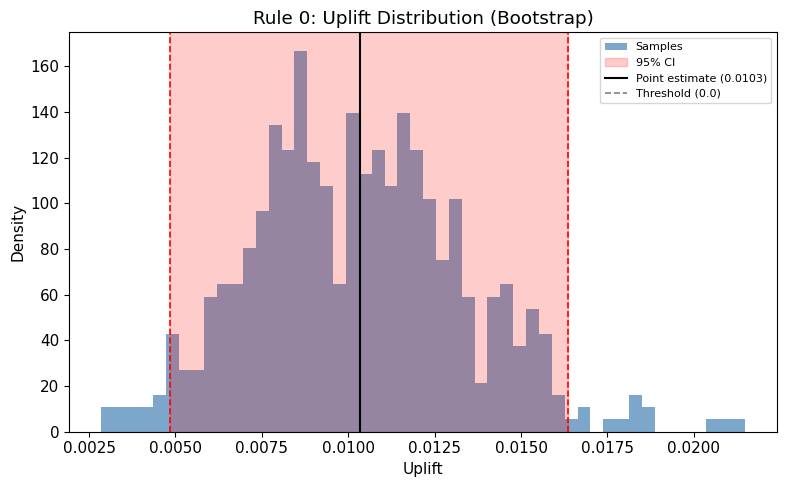

In [12]:
# Show the bootstrap distribution for the first rule
fig = bootstrap_histogram(results_boot[0], metric="uplift", threshold=0.0)
plt.tight_layout()

### 8.2 Posterior Distribution (Bayesian, Single Rule)

The Bayesian posterior plot shows the full probability distribution over the uplift parameter after observing the data. Unlike the bootstrap histogram (which shows a sampling distribution under the frequentist paradigm), this directly represents our **updated belief** about the true uplift.

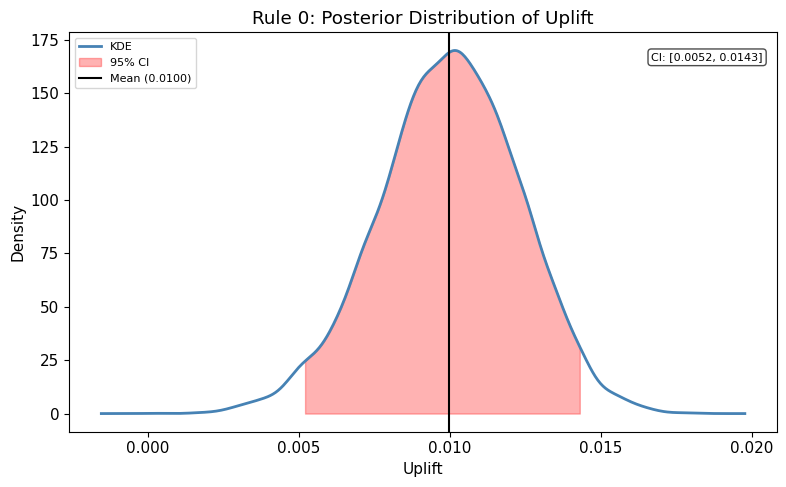

In [13]:
# Posterior distribution for the first rule (Bayesian method)
fig = posterior_plot(results_bayes[0], metric="uplift")
plt.tight_layout()

### 8.3 Forest Plot (All Rules, Bootstrap)

A forest plot is the standard visualization for multiple effect sizes with their confidence intervals. Each row is one rule; the dot is the point estimate and the horizontal bar is the 95% CI. Rules are color-coded by category (threshold = 0.0):

- **Green**: Accept — the entire CI is above 0 (significantly positive uplift)
- **Red**: Reject — the entire CI is below 0 (not beneficial)
- **Orange**: Uncertain — the CI crosses 0 (insufficient evidence)

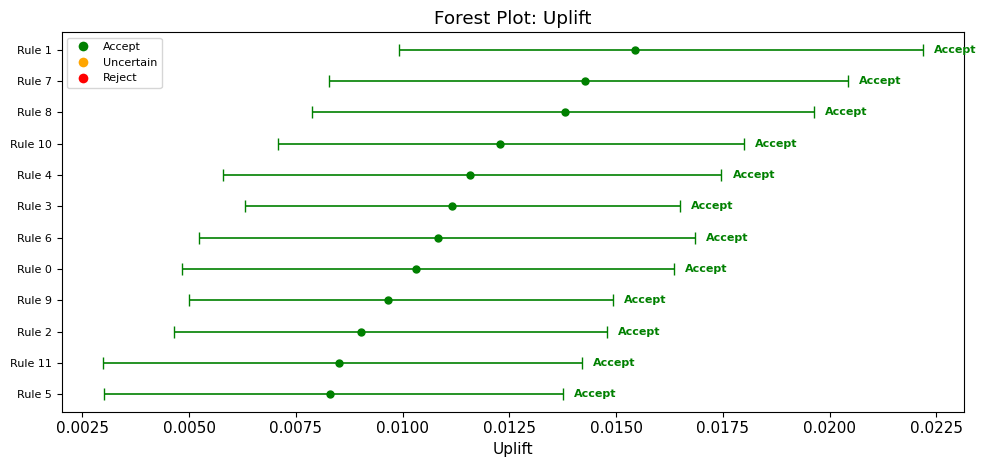

In [14]:
fig = forest_plot(results_boot, metric="uplift", threshold=0.0, show_categories=True)
plt.tight_layout()

### 8.4 Grouped Forest Plot (All Three Methods)

This plot overlays the bootstrap, analytic, and Bayesian CIs for each rule. Agreement across methods strengthens confidence in the result. Where methods diverge substantially — particularly for rules with small support counts — the data is insufficient to distinguish between methods and more data is needed.

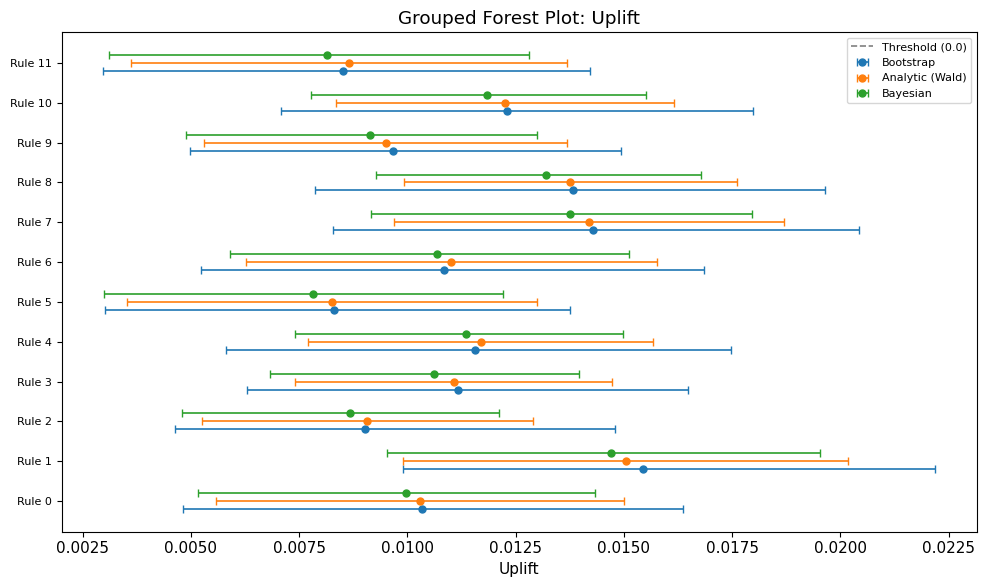

In [15]:
fig = grouped_forest_plot(
    {"Bootstrap": results_boot, "Analytic (Wald)": results_anal, "Bayesian": results_bayes},
    metric="uplift",
    threshold=0.0,
)
plt.tight_layout()

## 9. Rule Categorization: Accept, Reject, or Uncertain

In HR decision-making, you need a clear verdict: *should we implement this intervention or not?* The package provides automatic categorization based on whether the CI is entirely above, entirely below, or overlapping a decision threshold.

- **Accept**: the entire CI is above the threshold — the rule is statistically significant and worth deploying.
- **Reject**: the entire CI is below the threshold — the intervention is unlikely to be effective.
- **Uncertain**: the CI overlaps the threshold — collect more data before deciding.

This three-valued verdict is more informative than a binary accept/reject based on a p-value because it explicitly identifies rules where the evidence is ambiguous.

In [16]:
results_categorized = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    threshold=0.0,
    metric="uplift",
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>26} | {'Category':>12}")
print("-" * 68)
for r in results_categorized:
    cat = r.category.value if r.category else "N/A"
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {cat:>12}"
    )

  Rule |     Uplift |                     95% CI |     Category
--------------------------------------------------------------------
     0 |   0.010327 | [  0.004829,   0.016354] |       accept
     1 |   0.015435 | [  0.009907,   0.022193] |       accept
     2 |   0.009019 | [  0.004637,   0.014790] |       accept
     3 |   0.011170 | [  0.006307,   0.016491] |       accept
     4 |   0.011570 | [  0.005804,   0.017470] |       accept
     5 |   0.008298 | [  0.003016,   0.013764] |       accept
     6 |   0.010840 | [  0.005228,   0.016844] |       accept
     7 |   0.014279 | [  0.008276,   0.020424] |       accept
     8 |   0.013814 | [  0.007870,   0.019632] |       accept
     9 |   0.009667 | [  0.004991,   0.014934] |       accept
    10 |   0.012293 | [  0.007085,   0.017988] |       accept
    11 |   0.008518 | [  0.002977,   0.014208] |       accept


In [17]:
# Summarize category counts
from collections import Counter

category_counts = Counter(
    r.category.value for r in results_categorized if r.category is not None
)
print("Rule category summary (Bootstrap, threshold=0.0):")
for cat, count in sorted(category_counts.items()):
    pct = count / n_rules * 100
    print(f"  {cat:<12}: {count:>3} rules ({pct:.0f}%)")

Rule category summary (Bootstrap, threshold=0.0):
  accept      :  12 rules (100%)


## 10. Utility-Aware Analysis

Statistical uplift tells us *whether* an intervention changes attrition probability. But is the intervention *economically worthwhile*? The **realistic rule gain** integrates the uplift estimate with the utility tables to compute the expected net monetary value of applying a rule.

A rule with high positive uplift might still have a negative realistic gain if, for example, the required salary increase (transition cost) exceeds the expected savings from reduced attrition.

We compute bootstrap CIs for the realistic rule gain and visualize them with a forest plot.

In [18]:
results_gain = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    threshold=0.0,
    metric="realistic_rule_gain",
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Gain ($)':>12} | {'95% CI':>30} | {'Category':>12}")
print("-" * 72)
for r in results_gain:
    if r.realistic_rule_gain_point is not None:
        cat = r.category.value if r.category else "N/A"
        print(
            f"  {r.rule_index:>4} | {r.realistic_rule_gain_point:>12.2f} | "
            f"[{r.realistic_rule_gain_ci_lower:>12.2f}, {r.realistic_rule_gain_ci_upper:>12.2f}] | {cat:>12}"
        )

  Rule |     Gain ($) |                         95% CI |     Category
------------------------------------------------------------------------
     0 |      1986.66 | [     1094.15,      2839.67] |       accept
     1 |      2385.18 | [     1675.49,      3095.53] |       accept
     2 |      2390.82 | [     1468.24,      3273.44] |       accept
     3 |     -1052.64 | [    -2100.09,      -113.53] |       reject
     4 |      2694.61 | [     1823.71,      3557.30] |       accept
     5 |      1939.63 | [      866.17,      2985.03] |       accept
     6 |      2100.18 | [     1156.90,      2978.17] |       accept
     7 |     -1267.24 | [    -2165.47,      -472.60] |       reject
     8 |     -1829.40 | [    -2748.51,     -1002.00] |       reject
     9 |      2222.16 | [     1273.57,      3097.92] |       accept
    10 |     -1160.41 | [    -2044.69,      -264.21] |       reject
    11 |     -2093.81 | [    -3326.00,     -1039.79] |       reject


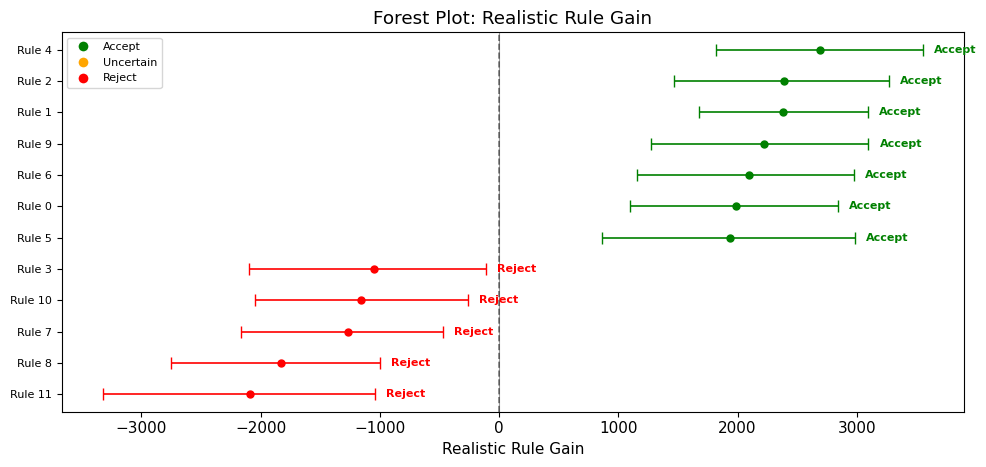

In [19]:
# Forest plot for realistic rule gain: which interventions are economically justified?
fig = forest_plot(results_gain, metric="realistic_rule_gain", threshold=0.0, show_categories=True)
plt.tight_layout()

## 11. Method Comparison

Let's compare all three CI methods on the realistic rule gain metric and summarize the results in a single DataFrame. This is the type of comparison table you would include in a research report or paper to demonstrate robustness of the findings.

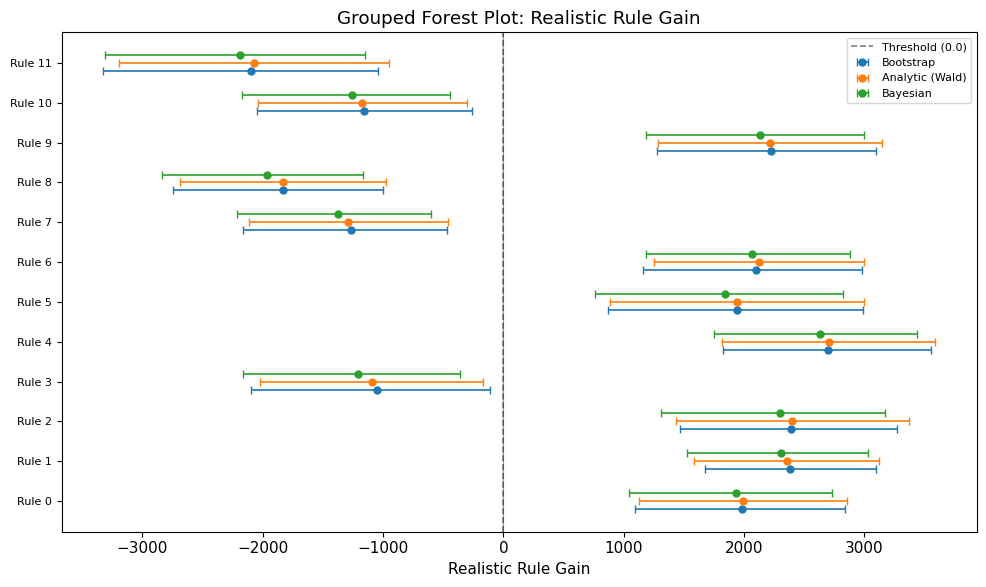

In [20]:
gain_boot = ar.confidence_intervals(
    data, method="bootstrap", confidence_level=0.95, n_bootstrap=500, random_state=42
)
gain_anal = ar.confidence_intervals(data, method="analytic", confidence_level=0.95)
gain_bayes = ar.confidence_intervals(
    data, method="bayesian", confidence_level=0.95, n_mc=10000, random_state=42
)

# Grouped forest plot for realistic rule gain across all three methods
fig = grouped_forest_plot(
    {"Bootstrap": gain_boot, "Analytic (Wald)": gain_anal, "Bayesian": gain_bayes},
    metric="realistic_rule_gain",
    threshold=0.0,
)
plt.tight_layout()

In [21]:
# Build a comparison DataFrame
rows = []
for method_name, results in [
    ("Bootstrap", gain_boot),
    ("Analytic", gain_anal),
    ("Bayesian", gain_bayes),
]:
    for r in results:
        rows.append(
            {
                "Rule": r.rule_index,
                "Method": method_name,
                "Gain": round(r.realistic_rule_gain_point, 6),
                "CI Lower": round(r.realistic_rule_gain_ci_lower, 6),
                "CI Upper": round(r.realistic_rule_gain_ci_upper, 6),
                "CI Width": round(r.realistic_rule_gain_ci_upper - r.realistic_rule_gain_ci_lower, 6),
            }
        )

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values(["Rule", "Method"]).reset_index(drop=True)
print(f"Comparison table shape: {comparison_df.shape}")
comparison_df

Comparison table shape: (36, 6)


,Rule,Method,Gain,CI Lower,CI Upper,CI Width
0,0,Analytic,1991.483516,1127.238466,2855.728567,1728.490101
1,0,Bayesian,1932.558740,1047.606109,2733.579739,1685.973629
2,0,Bootstrap,1986.664714,1094.146996,2839.665747,1745.518751
3,1,Analytic,2355.690738,1585.706448,3125.675028,1539.968580
4,1,Bayesian,2303.689484,1528.844637,3029.219672,1500.375034
5,1,Bootstrap,2385.181380,1675.494986,3095.532635,1420.037650
6,2,Analytic,2399.627213,1430.898958,3368.355469,1937.456511
7,2,Bayesian,2299.670827,1313.731972,3171.414785,1857.682813
8,2,Bootstrap,2390.815682,1468.235064,3273.436584,1805.201520
9,3,Analytic,-1094.581281,-2023.289874,-165.872688,1857.417187


## 12. Summary

This notebook demonstrated the full action rule mining and confidence interval workflow on the IBM HR Employee Attrition dataset. Key findings and takeaways:

### Practical findings
- The dataset has ~16% attrition rate, meaning most rules are mined from relatively few positive examples. This makes **confidence interval analysis essential** — many rules that appear promising on point estimates may have intervals that span zero.
- Rules involving **overtime reduction** and **job satisfaction improvement** tend to appear most frequently among mined rules, consistent with domain knowledge about major attrition drivers.
- The **realistic rule gain** analysis is valuable here: some high-uplift rules (e.g., large salary increases) may have negative expected gain when intervention costs are accounted for.

### Methodological observations
- **Bootstrap vs. Analytic**: With small sample sizes, the analytic (Wald) intervals can be noticeably narrower than bootstrap intervals. This is expected — the normal approximation tends to underestimate uncertainty when counts are small.
- **Bayesian advantage**: The Beta-Binomial model naturally regularizes small-sample estimates. When a rule has very few supporting examples, the Bayesian posterior is appropriately diffuse, reflecting genuine uncertainty rather than false precision.
- **Three-valued categorization**: The Accept/Reject/Uncertain framework is more honest than binary statistical significance testing, especially on small datasets where "Uncertain" is often the most appropriate verdict.

### Next steps
- Increase dataset size (more years of HR data, or synthetic augmentation) to reduce interval widths
- Tune utility tables to reflect organization-specific cost structures
- Use the JSON export (`rules.get_export_notation()`) to integrate discovered rules into HR decision-support systems